# 💳 Credit Card Fraud Detection & Risk Scoring System

## 📌 Project Overview

Credit card fraud is a major problem in the financial industry. A fraud detection system uses machine learning to identify suspicious transactions and distinguish them from legitimate transactions.

In this project, we will build an end-to-end **Credit Card Fraud Detection and Risk Scoring System** using the **IEEE-CIS Fraud Detection dataset**.

The project will focus not only on predicting fraud but also on handling the challenges of highly imbalanced data, optimizing the fraud detection threshold, and explaining why a transaction was classified as suspicious.

---

## 🎯 Project Objectives

The main objectives of this project are:

- Understand and explore the IEEE-CIS fraud detection dataset.
- Perform data cleaning and preprocessing.
- Analyze missing values and categorical/numerical features.
- Perform exploratory data analysis (EDA).
- Identify patterns associated with fraudulent transactions.
- Handle the highly imbalanced target variable.
- Perform feature engineering.
- Build baseline machine learning models.
- Train advanced models such as XGBoost.
- Tune the best-performing model.
- Evaluate models using appropriate fraud-detection metrics.
- Optimize the classification threshold based on business requirements.
- Generate a fraud probability and risk score for each transaction.
- Use Explainable AI (SHAP) to understand model predictions.
- Deploy the final model through a FastAPI backend.
- Build a frontend dashboard for real-time fraud risk prediction.

---

## 📊 Dataset

The project uses the **IEEE-CIS Fraud Detection dataset**.

The dataset contains two main training files:

- `train_transaction.csv` — transaction-related information.
- `train_identity.csv` — identity and device-related information.

These datasets are joined using the common:

`TransactionID`

After merging, the resulting dataset is stored as:

`train_merged.csv`

### Target Variable

The target variable is:

- `isFraud = 0` → Legitimate transaction
- `isFraud = 1` → Fraudulent transaction

---

## ⚠️ Why Fraud Detection Is Challenging

Fraud detection is an **imbalanced classification problem** because fraudulent transactions represent only a small percentage of all transactions.

Therefore, accuracy alone is not a reliable metric.

For example, a model could achieve very high accuracy by predicting almost every transaction as legitimate while still failing to detect many fraudulent transactions.

Therefore, this project will focus on:

- **Precision**
- **Recall**
- **F1-Score**
- **ROC-AUC**
- **PR-AUC**
- **Confusion Matrix**

We will also analyze the trade-off between false positives and false negatives.

---

## 💡 Project Uniqueness

Instead of building a simple fraud/not-fraud classifier, this project will be developed as a **Fraud Risk Scoring System**.

The final system will provide:

### 1. Fraud Probability

Example:

`Fraud Probability = 91.7%`

### 2. Risk Score

Example:

`Risk Score = 92 / 100`

### 3. Risk Level

- **Low Risk**
- **Medium Risk**
- **High Risk**

### 4. Explainable Prediction

Using SHAP, the system will identify the major factors that contributed to a transaction being classified as suspicious.

### 5. Cost-Sensitive Decision Making

Instead of blindly using a probability threshold of `0.50`, we will investigate an appropriate threshold based on the relative business cost of:

- False Positives
- False Negatives

---

## 🏗️ Project Workflow

```text
Raw Dataset
     ↓
Data Understanding
     ↓
Data Cleaning
     ↓
Exploratory Data Analysis
     ↓
Feature Engineering
     ↓
Train/Test Split
     ↓
Imbalance Handling
     ↓
Baseline Models
     ↓
Model Comparison
     ↓
Hyperparameter Tuning
     ↓
Threshold Optimization
     ↓
SHAP Explainability
     ↓
Fraud Risk Scoring
     ↓
FastAPI Backend
     ↓
Frontend Dashboard

Then create your **next Markdown cell**:

```markdown
# 1. Import Required Libraries

In this section, we import the Python libraries required for data loading, manipulation, visualization, statistical analysis, and machine learning.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [107]:
# Load the merged dataset
df = pd.read_csv("../data/train_merged.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (590540, 434)


In [108]:
df.head(3)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [109]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [111]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df.head(30)

,Missing Values,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [112]:
print(df.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=434)


In [113]:
# Display the first 5 rows with all columns

pd.set_option("display.max_columns", None)

df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

# EDA

## 3. Dataset Overview

Before performing detailed exploratory analysis, we first examine the overall structure of the dataset.

The purpose of this section is to understand:

- Number of transactions
- Number of features
- Data types
- Dataset memory usage
- First and last records
- Target variable

In [114]:
# Dataset shape

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 590540
Number of columns : 434


In [115]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [116]:
df.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [118]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


## 4. Target Variable Analysis

The target variable in this project is `isFraud`.

- `0` represents a legitimate transaction.
- `1` represents a fraudulent transaction.

Fraud detection datasets are usually highly imbalanced, meaning that fraudulent transactions represent a small proportion of all transactions.

Therefore, understanding the class distribution is essential before building any machine learning model.

In [119]:
fraud_ana= df['isFraud'].value_counts()

print(fraud_ana)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [120]:
fraud_pre= df['isFraud'].value_counts(normalize=True)*100

print(fraud_pre)

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


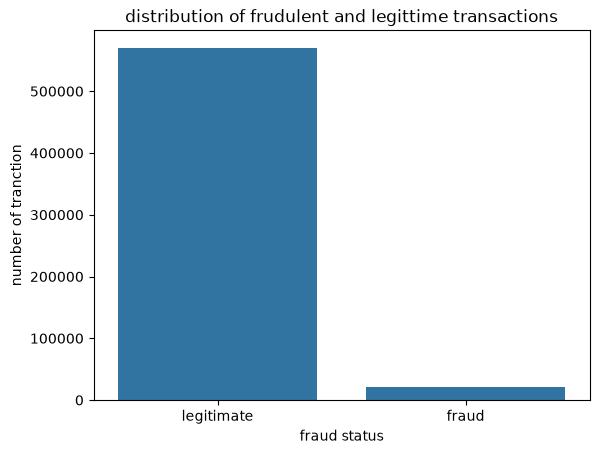

In [121]:
plt.Figure(figsize=(8,15))

sns.countplot(
    x="isFraud",
    data=df,
)
plt.title('distribution of frudulent and legittime transactions')
plt.xlabel('fraud status')
plt.ylabel('number of tranction')

plt.xticks([0,1],['legitimate','fraud'])
plt.show()

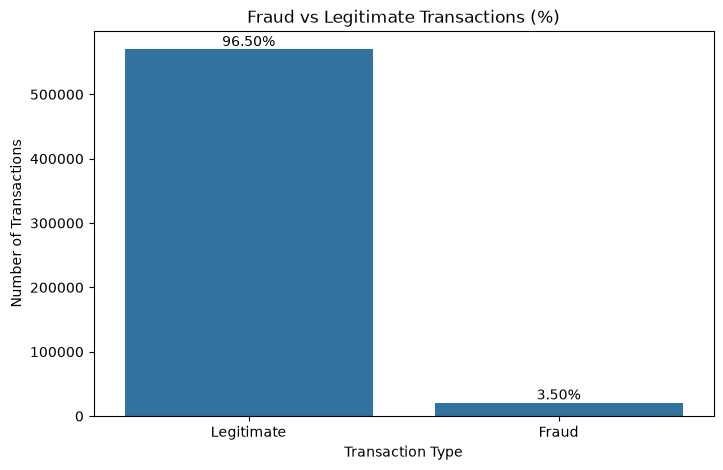

In [122]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="isFraud"
)

total = len(df)

for container in ax.containers:
    labels = [
        f"{(value / total) * 100:.2f}%"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels)

plt.title("Fraud vs Legitimate Transactions (%)")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

## 5. Missing Value Analysis

Missing values are an important characteristic of the IEEE-CIS dataset.

In this section, we will:

- Count missing values in every feature.
- Calculate missing-value percentages.
- Identify features with extremely high missingness.
- Visualize the most incomplete features.

We will not remove missing values at this stage because the pattern of missingness itself may contain useful information for fraud detection.

In [123]:
# Calculate missing values

missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df.head(30)

,Missing Values,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [124]:
# Number of features containing missing values

features_with_missing = (
    missing_df["Missing Values"] > 0
).sum()

print(
    "Features containing missing values:",
    features_with_missing
)

Features containing missing values: 414


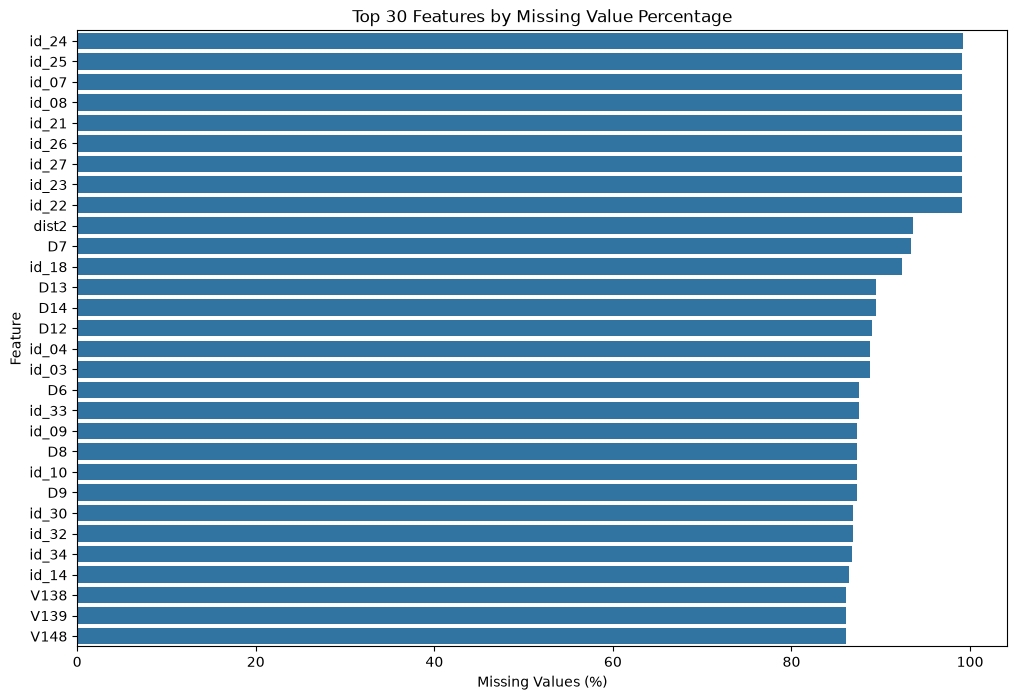

In [125]:
plt.figure(figsize=(12, 8))

top_missing = missing_df.head(30)

sns.barplot(
    data=top_missing,
    x="Missing Percentage",
    y=top_missing.index
)

plt.title("Top 30 Features by Missing Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.show()

## 6. Duplicate Transaction Analysis

Duplicate records can affect model training and evaluation.

In this section, we check whether the merged dataset contains completely duplicated rows.

We will also verify whether `TransactionID` is unique.

In [126]:
# Check TransactionID uniqueness

print(
    "Total Transaction IDs:",
    df["TransactionID"].nunique()
)

print(
    "Total rows:",
    len(df)
)

Total Transaction IDs: 590540
Total rows: 590540


## 7. Numerical Feature Analysis

The dataset contains many numerical features.

However, numerical-looking features are not necessarily continuous numerical variables. Some anonymized features may actually represent categorical or encoded information.

We begin by examining the distribution of numerical features and their basic statistics.

We will initially focus on important known numerical variables such as:

- `TransactionAmt`
- `TransactionDT`

In [127]:
# Analyze important numerical features

df[
    ["TransactionAmt", "TransactionDT"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.0,3.193739e+04
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.0,1.581113e+07


## 8. Transaction Amount Analysis

`TransactionAmt` represents the transaction amount.

We will investigate:

- Distribution of transaction amounts.
- Typical transaction value.
- Presence of extreme values.
- Difference between fraudulent and legitimate transaction amounts.

The goal is to determine whether transaction amount provides useful information for fraud detection.

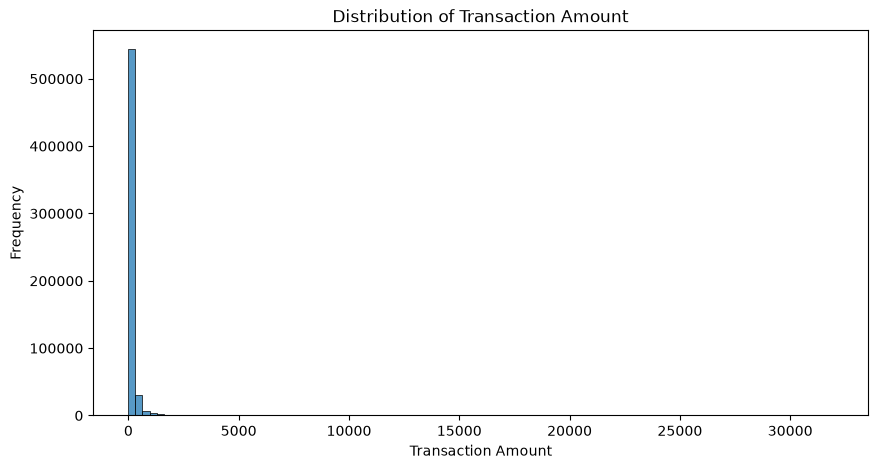

In [128]:
# Distribution of transaction amount

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TransactionAmt",
    bins=100
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

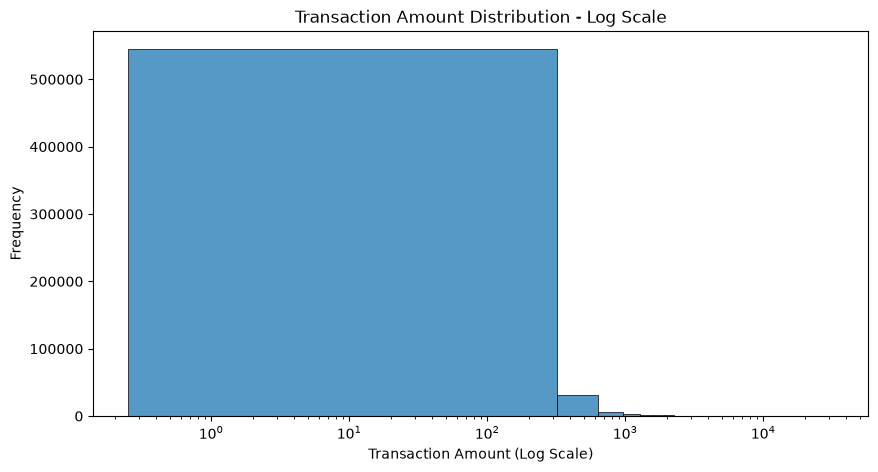

In [129]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TransactionAmt",
    bins=100
)

plt.xscale("log")

plt.title("Transaction Amount Distribution - Log Scale")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Frequency")

plt.show()

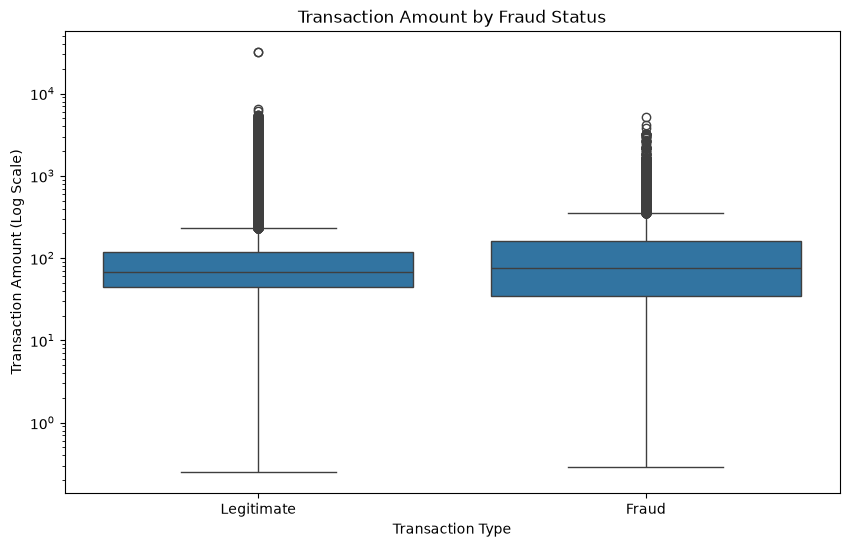

In [130]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="TransactionAmt"
)

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (Log Scale)")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [131]:
df.groupby("isFraud")["TransactionAmt"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
isFraud,,,,,
0,569877,134.511665,68.5,0.251,31937.391
1,20663,149.244779,75.0,0.292,5191.000


## 9. Transaction Time Analysis

`TransactionDT` represents the time elapsed from a reference point.

Time can be an important fraud signal because fraudulent activity may have different temporal patterns from legitimate activity.

We will analyze:

- TransactionDT distribution.
- Fraudulent transactions over time.
- Fraud rate over time.

Later, we can engineer features such as hour, day, and time period.

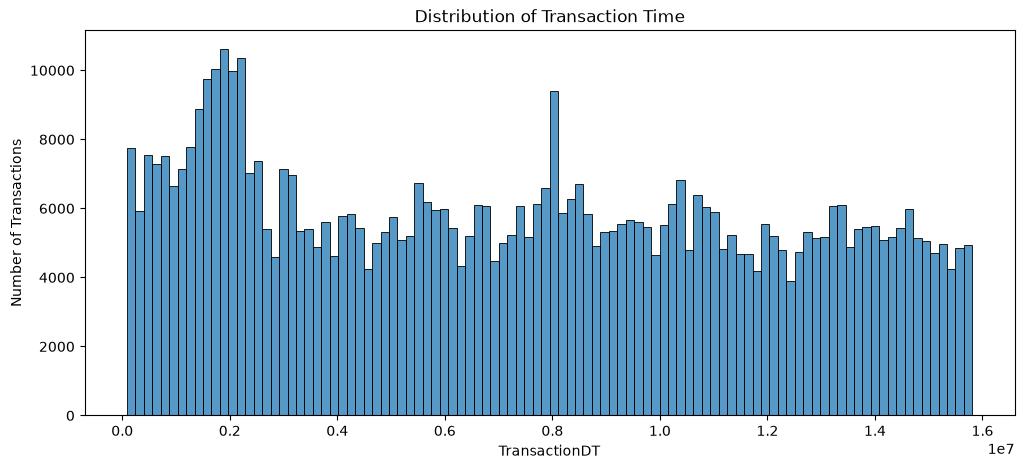

In [132]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="TransactionDT",
    bins=100
)

plt.title("Distribution of Transaction Time")
plt.xlabel("TransactionDT")
plt.ylabel("Number of Transactions")

plt.show()

In [133]:
# Create time intervals using TransactionDT

df["time_bin"] = pd.qcut(
    df["TransactionDT"],
    q=50,
    duplicates="drop"
)

# Calculate fraud rate for each time interval

fraud_over_time = (
    df.groupby("time_bin", observed=True)["isFraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

fraud_over_time.rename(
    columns={
        "count": "Total_Transactions",
        "sum": "Fraud_Transactions",
        "mean": "Fraud_Rate"
    },
    inplace=True
)

fraud_over_time.head()

C:\Users\hasher\AppData\Local\Temp\ipykernel_14564\3415472281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["time_bin"] = pd.qcut(


,time_bin,Total_Transactions,Fraud_Transactions,Fraud_Rate
0,"(86399.999, 341704.78]",11811,321,0.027178
1,"(341704.78, 601968.8]",11811,344,0.029125
2,"(601968.8, 863015.8]",11811,350,0.029633
3,"(863015.8, 1120681.12]",11811,291,0.024638
4,"(1120681.12, 1361004.4]",11810,325,0.027519


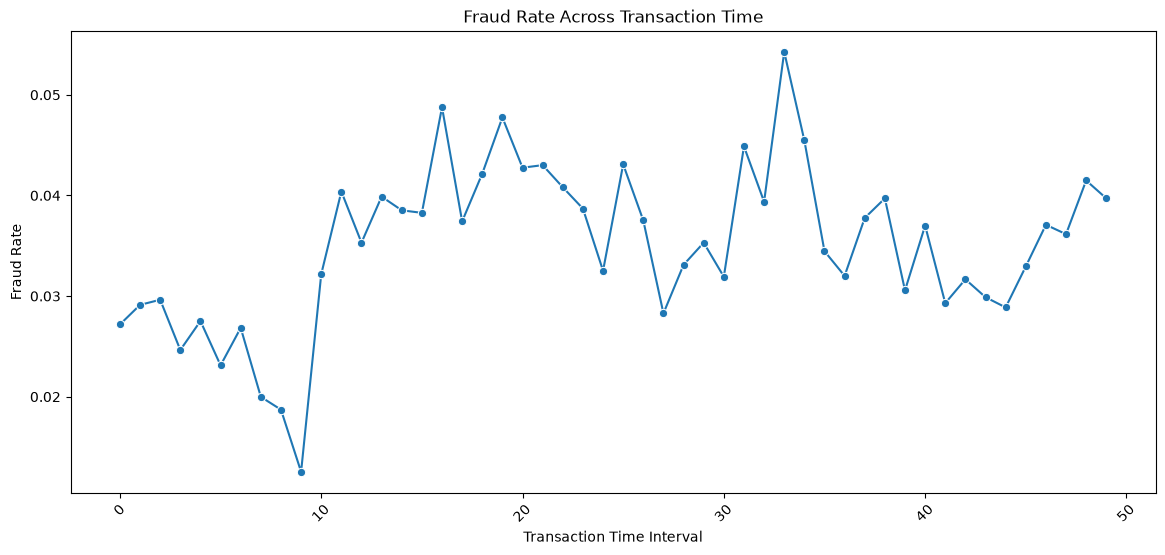

In [134]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=fraud_over_time,
    x=fraud_over_time.index,
    y="Fraud_Rate",
    marker="o"
)

plt.title("Fraud Rate Across Transaction Time")
plt.xlabel("Transaction Time Interval")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

## 10. Categorical Feature Analysis

Categorical variables can contain important information about transaction behavior.

We will initially analyze selected categorical features:

- `ProductCD`
- `card4`
- `card6`
- `P_emaildomain`
- `R_emaildomain`
- `DeviceType`

We will examine their frequency distributions and relationship with fraud.

In [135]:
categorical_features = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "DeviceType"
]

for column in categorical_features:
    print(f"\n{'=' * 50}")
    print(column)
    print(f"{'=' * 50}")
    print(df[column].value_counts(dropna=False).head(15))


ProductCD
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

card4
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

card6
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

P_emaildomain
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
Name: count, dtype: int64

R_emaildomain
R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com 

In [136]:
product_fraud = (
    df.groupby("ProductCD")["isFraud"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

product_fraud

,count,sum,mean
ProductCD,,,
C,68519,8008,0.116873
S,11628,686,0.058996
H,33024,1574,0.047662
R,37699,1426,0.037826
W,439670,8969,0.020399


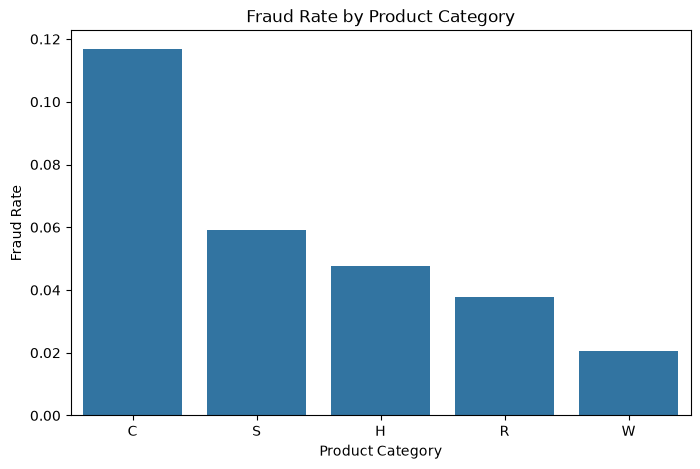

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_fraud.reset_index(),
    x="ProductCD",
    y="mean"
)

plt.title("Fraud Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Fraud Rate")

plt.show()

## 12. Device Type vs Fraud

Device information can provide useful behavioral signals.

We will investigate whether fraudulent transactions have a different distribution across device types.

In [138]:
device_fraud = (
    df.groupby("DeviceType")["isFraud"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

device_fraud

,count,sum,mean
DeviceType,,,
mobile,55645,5657,0.101662
desktop,85165,5554,0.065215


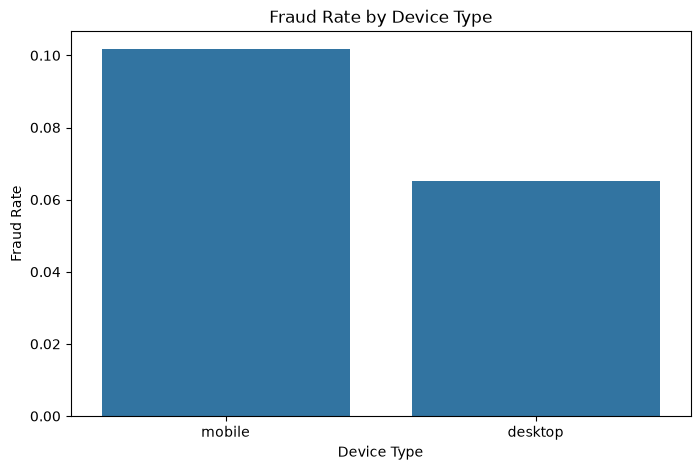

In [139]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_fraud.reset_index(),
    x="DeviceType",
    y="mean"
)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate")

plt.show()

## 13. Email Domain Analysis

Email domains can provide useful information about transaction behavior.

We will analyze the most common purchaser email domains and compare their fraud rates.

Because there may be many unique domains, we will initially focus on the most frequent domains.

In [140]:
top_email_domains = (
    df["P_emaildomain"]
    .value_counts()
    .head(15)
    .index
)

email_subset = df[
    df["P_emaildomain"].isin(top_email_domains)
]

email_fraud = (
    email_subset
    .groupby("P_emaildomain")["isFraud"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

email_fraud

,count,mean
P_emaildomain,,
outlook.com,5096,0.094584
hotmail.com,45250,0.052950
gmail.com,228355,0.043542
icloud.com,6267,0.031434
comcast.net,7888,0.031187
bellsouth.net,1909,0.027763
live.com,3041,0.027622
anonymous.com,36998,0.023217
yahoo.com,100934,0.022757


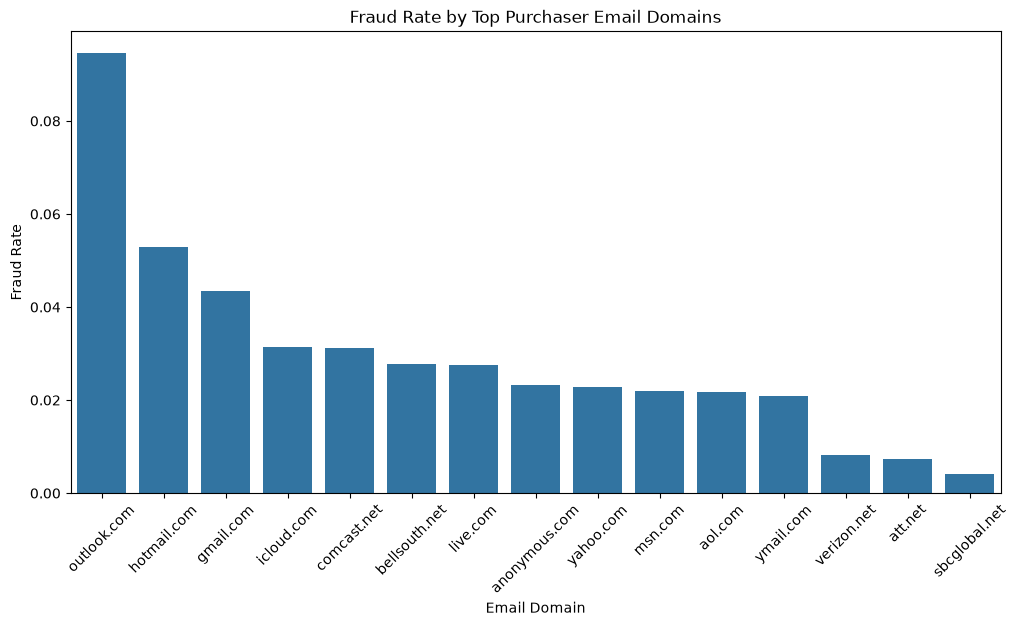

In [141]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=email_fraud.reset_index(),
    x="P_emaildomain",
    y="mean"
)

plt.xticks(rotation=45)

plt.title("Fraud Rate by Top Purchaser Email Domains")
plt.xlabel("Email Domain")
plt.ylabel("Fraud Rate")

plt.show()

## 14. Correlation Analysis

Correlation analysis helps us understand relationships between numerical variables.

Because the dataset contains hundreds of features, generating a correlation heatmap for every feature would be difficult to interpret.

Therefore, we initially examine the correlation of selected important numerical variables with the target variable.

In [142]:
correlation_features = [
    "isFraud",
    "TransactionAmt",
    "TransactionDT"
]

correlation_matrix = df[
    correlation_features
].corr()

correlation_matrix

,isFraud,TransactionAmt,TransactionDT
isFraud,1.000000,0.01132,0.013103
TransactionAmt,0.011320,1.00000,0.011920
TransactionDT,0.013103,0.01192,1.000000


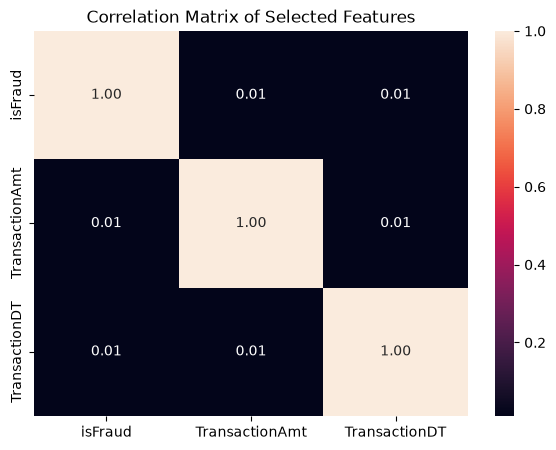

In [143]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Selected Features")

plt.show()

##  EDA Findings & Key Insights

### Dataset Structure

- The dataset contains a large number of transaction and identity-related features.
- Transaction and identity information were merged using `TransactionID`.
- The target variable is `isFraud`.

### Class Imbalance

- Fraudulent transactions represent a small proportion of the dataset.
- Therefore, accuracy alone will not be sufficient for evaluating our models.
- Precision, Recall, F1-Score, ROC-AUC and PR-AUC will be considered.

### Missing Values

- Several features contain significant amounts of missing data.
- Missingness may itself contain predictive information.
- Missing values will therefore be handled carefully rather than removed blindly.

### Transaction Amount

- Transaction amounts show a skewed distribution.
- Fraudulent and legitimate transactions will be compared to determine whether transaction amount provides useful predictive information.

### Transaction Time

- Transaction time may contain behavioral patterns associated with fraudulent activity.
- Time-based features may be engineered during preprocessing.

### Categorical Features

- Product category, card attributes, email domains and device type may show different fraud rates.
- These features will require appropriate categorical encoding during preprocessing.

### Identity Information

- Identity information is missing for many transactions.
- The relationship between identity availability and fraud will be investigated further.

### Next Step

Based on the EDA findings, the next stage will be:

**Data Cleaning → Feature Engineering → Train/Test Split → Preprocessing → Handling Class Imbalance**

# Data Cleaning

After completing exploratory data analysis, we now clean the dataset before machine learning.

The IEEE-CIS dataset contains a large number of numerical and categorical features, substantial missing values, skewed distributions, and anonymized features.

The cleaning process will focus on:

1. Identifying useless or inappropriate columns.
2. Analyzing missing values.
3. Detecting potential outliers.
4. Measuring feature skewness.
5. Removing or transforming features only when justified.
6. Handling missing values using appropriate strategies.
7. Validating the cleaned dataset.

### Important Principle

We will not automatically remove every outlier or highly skewed feature.

In fraud detection, unusual values may represent genuine fraudulent behavior and can therefore contain important predictive information.

All cleaning decisions will be based on data analysis and model requirements.

In [144]:
# Create a separate copy for data cleaning

clean_df = df.copy()

print("Original shape :", df.shape)
print("Cleaning shape :", clean_df.shape)

Original shape : (590540, 435)
Cleaning shape : (590540, 435)


### A feature may be considered low-information if:

- It contains only one unique value.
- It contains almost the same value for every transaction.
- It is purely an identifier and does not represent transaction behavior.
- It duplicates another feature.

In [145]:
# Find columns with only one unique value

constant_columns = [
    column
    for column in clean_df.columns
    if clean_df[column].nunique(dropna=False) <= 1
]

print("Number of constant columns:", len(constant_columns))
print("\nConstant columns:")
print(constant_columns)

Number of constant columns: 0

Constant columns:
[]


## Missing Value Analysis

The IEEE-CIS dataset contains many features with substantial missing values.

Missing values will be analyzed before imputation because blindly filling every missing value can destroy useful information.

For each feature we will examine:

- Number of missing values.
- Percentage of missing values.
- Data type.
- Number of unique values.

Features with extremely high missingness will be investigated separately rather than automatically removed.

In [146]:
# Create missing-value summary

missing_summary = pd.DataFrame({
    "Missing_Count": clean_df.isnull().sum(),
    "Missing_Percentage": (
        clean_df.isnull().mean() * 100
    ),
    "Data_Type": clean_df.dtypes,
    "Unique_Values": clean_df.nunique(dropna=False)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_summary.head(30)

,Missing_Count,Missing_Percentage,Data_Type,Unique_Values
id_24,585793,99.196159,float64,13
id_25,585408,99.130965,float64,342
id_07,585385,99.127070,float64,85
id_08,585385,99.127070,float64,95
id_21,585381,99.126393,float64,491
id_26,585377,99.125715,float64,96
id_27,585371,99.124699,str,3
id_23,585371,99.124699,str,4
id_22,585371,99.124699,float64,26
dist2,552913,93.628374,float64,1752


In [147]:
# Categorize columns according to missing percentage

def missing_category(percent):

    if percent == 0:
        return "No Missing Values"

    elif percent < 20:
        return "Low Missingness"

    elif percent < 50:
        return "Moderate Missingness"

    elif percent < 80:
        return "High Missingness"

    elif percent < 95:
        return "Very High Missingness"

    else:
        return "Extreme Missingness"


missing_summary["Missing_Category"] = (
    missing_summary["Missing_Percentage"]
    .apply(missing_category)
)

missing_summary["Missing_Category"].value_counts()

Missing_Category
Low Missingness          162
High Missingness         140
Very High Missingness     65
Moderate Missingness      38
No Missing Values         21
Extreme Missingness        9
Name: count, dtype: int64

In [148]:
# Does missingness itself relate to fraud?

high_missing_features = (
    missing_summary[
        missing_summary["Missing_Percentage"] > 90
    ].index
)

missing_fraud_analysis = []

for column in high_missing_features:

    missing_flag = clean_df[column].isna()

    fraud_rate_missing = clean_df.loc[
        missing_flag,
        "isFraud"
    ].mean()

    fraud_rate_present = clean_df.loc[
        ~missing_flag,
        "isFraud"
    ].mean()

    missing_fraud_analysis.append({
        "Feature": column,
        "Missing_Percentage":
            missing_flag.mean() * 100,
        "Fraud_Rate_When_Missing":
            fraud_rate_missing * 100,
        "Fraud_Rate_When_Present":
            fraud_rate_present * 100
    })

missing_fraud_analysis = pd.DataFrame(
    missing_fraud_analysis
)

missing_fraud_analysis.sort_values(
    "Fraud_Rate_When_Missing",
    ascending=False
).head(20)

,Feature,Missing_Percentage,Fraud_Rate_When_Missing,Fraud_Rate_When_Present
0,id_24,99.196159,3.458730,8.468506
1,id_25,99.130965,3.458443,8.125487
5,id_26,99.125715,3.457259,8.231648
6,id_27,99.124699,3.457124,8.241439
7,id_23,99.124699,3.457124,8.241439
8,id_22,99.124699,3.457124,8.241439
4,id_21,99.126393,3.457065,8.257414
2,id_07,99.127070,3.457041,8.263822
3,id_08,99.127070,3.457041,8.263822
11,id_18,92.360721,3.103623,8.279210


## Outlier Analysis

Outliers are observations that are unusually far from the typical range of a feature.

In fraud detection, outliers require special care.

An unusually large transaction, for example, may be a genuine fraudulent transaction rather than an error.

Therefore, we will:

- Detect outliers.
- Measure their frequency.
- Compare outlier rates between fraud and legitimate transactions.
- Avoid automatically deleting them.

In [149]:
outlier_features = [
    "TransactionAmt",
    "TransactionDT"
]

In [150]:
def calculate_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )

    return {
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers.sum(),
        "Outlier_Percentage": outliers.mean() * 100
    }


outlier_results = []

for column in outlier_features:

    result = calculate_iqr_outliers(
        clean_df,
        column
    )

    outlier_results.append(result)


outlier_results = pd.DataFrame(
    outlier_results
)

outlier_results

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,TransactionAmt,43.321,125.0,81.679,-7.919750e+01,2.475185e+02,66482,11.257832
1,TransactionDT,3027057.750,11246620.0,8219562.250,-9.302286e+06,2.357596e+07,0,0.000000


In [151]:
# Analyze TransactionAmt outliers

Q1 = clean_df["TransactionAmt"].quantile(0.25)
Q3 = clean_df["TransactionAmt"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

amount_outlier = (
    clean_df["TransactionAmt"] > upper_bound
)

print(
    "Outlier transactions:",
    amount_outlier.sum()
)

print(
    "Fraud rate among outliers:",
    clean_df.loc[
        amount_outlier,
        "isFraud"
    ].mean() * 100
)

print(
    "Fraud rate among non-outliers:",
    clean_df.loc[
        ~amount_outlier,
        "isFraud"
    ].mean() * 100
)

Outlier transactions: 66482
Fraud rate among outliers: 5.072049577329202
Fraud rate among non-outliers: 3.299443954676772


##  Skewness Analysis

Skewness measures the asymmetry of a feature's distribution.

A positively skewed feature has a long right tail, while a negatively skewed feature has a long left tail.

Highly skewed numerical features may benefit from transformations such as logarithmic transformation.

However, tree-based models such as XGBoost generally do not require normally distributed features.

Therefore, skewness will be measured and analyzed rather than automatically corrected.

In [152]:
# Select numerical columns

numeric_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

# Calculate skewness

skewness = clean_df[numeric_columns].skew(
    numeric_only=True
)

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values,
    "Absolute_Skewness": skewness.abs().values
})

skewness_df = skewness_df.sort_values(
    "Absolute_Skewness",
    ascending=False
)

skewness_df.head(30)

,Feature,Skewness,Absolute_Skewness
345,V305,384.226170,384.226170
351,V311,323.831374,323.831374
169,V129,240.274253,240.274253
349,V309,224.875268,224.875268
246,V206,207.881617,207.881617
359,V319,181.833654,181.833654
309,V269,177.838951,177.838951
306,V266,175.958772,175.958772
374,V334,168.472807,168.472807
175,V135,144.883182,144.883182


In [153]:
# Select top 10 most skewed numerical features

top_skewed = (
    skewness_df
    .head(10)["Feature"]
    .tolist()
)

print(top_skewed)

['V305', 'V311', 'V129', 'V309', 'V206', 'V319', 'V269', 'V266', 'V334', 'V135']


### Outlier Analysis Finding

The IQR method identified 66,482 transactions as outliers for `TransactionAmt`.

The fraud rate among these transactions was approximately 5.07%, compared with 3.30% among non-outlier transactions.

Therefore, these observations were not removed because the outlier group showed a higher fraud rate and may contain meaningful fraud-related information.

Outlier detection will therefore be treated as an analytical feature rather than an automatic data-removal rule.

In [154]:
# Create a feature information summary

feature_summary = pd.DataFrame({
    "Data_Type": clean_df.dtypes,
    "Unique_Values": clean_df.nunique(dropna=False),
    "Missing_Percentage": clean_df.isnull().mean() * 100
})

# Calculate dominant value percentage
dominant_percentages = []

for column in clean_df.columns:
    
    value_counts = clean_df[column].value_counts(
        dropna=False,
        normalize=True
    )
    
    if len(value_counts) > 0:
        dominant_percentages.append(
            value_counts.iloc[0] * 100
        )
    else:
        dominant_percentages.append(100)

feature_summary["Dominant_Value_Percentage"] = (
    dominant_percentages
)

feature_summary.sort_values(
    "Unique_Values"
).head(30)

,Data_Type,Unique_Values,Missing_Percentage,Dominant_Value_Percentage
isFraud,int64,2,0.000000,96.500999
DeviceType,str,3,76.155722,76.155722
M2,str,3,45.907136,48.340163
M1,str,3,45.907136,54.088631
M8,str,3,58.633115,58.633115
M7,str,3,58.635317,58.635317
M6,str,3,28.678836,38.584347
M3,str,3,45.907136,45.907136
M9,str,3,58.633115,58.633115
V1,float64,3,47.293494,52.703627


In [155]:
constant_columns = [
    col for col in clean_df.columns
    if clean_df[col].nunique(dropna=False) <= 1
]

print("Number of constant columns:", len(constant_columns))
print(constant_columns)

Number of constant columns: 0
[]


In [156]:
clean_df = clean_df.drop(
    columns=constant_columns,
    errors="ignore"
)

print("New dataset shape:", clean_df.shape)

New dataset shape: (590540, 435)


In [157]:
transaction_ids = clean_df["TransactionID"].copy()

clean_df = clean_df.drop(
    columns=["TransactionID"],
    errors="ignore"
)

print("TransactionID removed from model features")

TransactionID removed from model features


In [158]:
X = clean_df.drop(columns=["isFraud"])
y = clean_df["isFraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (590540, 433)
Target shape: (590540,)


In [159]:
print(y.value_counts())

print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

isFraud
0    569877
1     20663
Name: count, dtype: int64

Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


# Train-Test Split

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (472432, 433)
X_test: (118108, 433)
y_train: (472432,)
y_test: (118108,)


In [161]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 401
Categorical features: 32


C:\Users\hasher\AppData\Local\Temp\ipykernel_14564\3431449531.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


# creating pipline


In [162]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [163]:
from sklearn.preprocessing import OrdinalEncoder

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

In [164]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [165]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [166]:
model_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [167]:
model_pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


c:\Users\hasher\OneDrive\Desktop\creit-card\creditvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [168]:
y_pred = model_pipeline.predict(X_test)

y_prob = model_pipeline.predict_proba(X_test)[:, 1]

In [169]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89    113975
           1       0.12      0.72      0.21      4133

    accuracy                           0.81    118108
   macro avg       0.56      0.77      0.55    118108
weighted avg       0.96      0.81      0.87    118108


Confusion Matrix:
[[92858 21117]
 [ 1138  2995]]

ROC-AUC Score:
0.8560601840099856

PR-AUC Score:
0.4231122828796604


In [170]:
import joblib

joblib.dump(model_pipeline, "fraud_detection_pipeline.pkl")

print("Model pipeline saved successfully!")

Model pipeline saved successfully!


In [171]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [173]:
loaded_model = joblib.load("fraud_detection_pipeline.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 0
Fraud Probability: 0.11207290577425658


In [178]:
import json
import pandas as pd
import numpy as np

# Get one complete test row
sample = X_test.iloc[0].copy()

# Convert to dictionary
sample_dict = {}

for key, value in sample.items():

    # Missing values
    if pd.isna(value):
        sample_dict[key] = None

    # NumPy integer
    elif isinstance(value, np.integer):
        sample_dict[key] = int(value)

    # NumPy float
    elif isinstance(value, np.floating):
        sample_dict[key] = float(value)

    # Normal JSON values
    elif isinstance(value, (str, int, float, bool)):
        sample_dict[key] = value

    # Other objects
    else:
        sample_dict[key] = str(value)


# Create JSON
sample_json = json.dumps(
    sample_dict,
    indent=2,
    allow_nan=False
)

# IMPORTANT: Check that it is valid JSON
json.loads(sample_json)

print("JSON is valid!")

# Save the complete JSON to a file
with open("sample_transaction.json", "w", encoding="utf-8") as f:
    f.write(sample_json)

print(sample_json)

JSON is valid!
{
  "TransactionDT": 7864752,
  "TransactionAmt": 107.95,
  "ProductCD": "W",
  "card1": 7585,
  "card2": 553.0,
  "card3": 150.0,
  "card4": "visa",
  "card5": 226.0,
  "card6": "credit",
  "addr1": 264.0,
  "addr2": 87.0,
  "dist1": 19.0,
  "dist2": null,
  "P_emaildomain": "aol.com",
  "R_emaildomain": null,
  "C1": 2.0,
  "C2": 2.0,
  "C3": 0.0,
  "C4": 0.0,
  "C5": 1.0,
  "C6": 2.0,
  "C7": 0.0,
  "C8": 0.0,
  "C9": 1.0,
  "C10": 0.0,
  "C11": 1.0,
  "C12": 0.0,
  "C13": 9.0,
  "C14": 2.0,
  "D1": 122.0,
  "D2": 122.0,
  "D3": 33.0,
  "D4": 216.0,
  "D5": 33.0,
  "D6": null,
  "D7": null,
  "D8": null,
  "D9": null,
  "D10": 33.0,
  "D11": 216.0,
  "D12": null,
  "D13": null,
  "D14": null,
  "D15": 216.0,
  "M1": "T",
  "M2": "T",
  "M3": "F",
  "M4": null,
  "M5": null,
  "M6": "T",
  "M7": "F",
  "M8": "F",
  "M9": "T",
  "V1": 1.0,
  "V2": 1.0,
  "V3": 1.0,
  "V4": 1.0,
  "V5": 1.0,
  "V6": 1.0,
  "V7": 1.0,
  "V8": 1.0,
  "V9": 1.0,
  "V10": 1.0,
  "V11": 1.0,


In [179]:
import json

# Save complete valid JSON
with open("sample_transaction.json", "w", encoding="utf-8") as f:
    f.write(sample_json)

print("sample_transaction.json saved successfully!")

sample_transaction.json saved successfully!


In [180]:
import joblib

# Take one non-fraud transaction as the default reference
reference_row = X_test[y_test == 0].iloc[[0]].copy()

# Save it
joblib.dump(
    reference_row,
    "reference_transaction.pkl"
)

print("Reference transaction saved successfully!")

Reference transaction saved successfully!
